Task 1

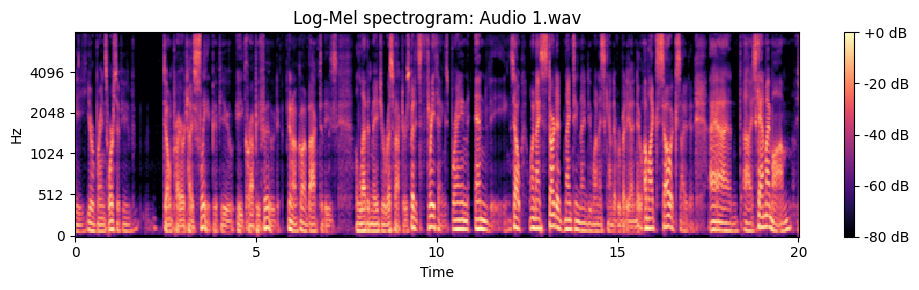

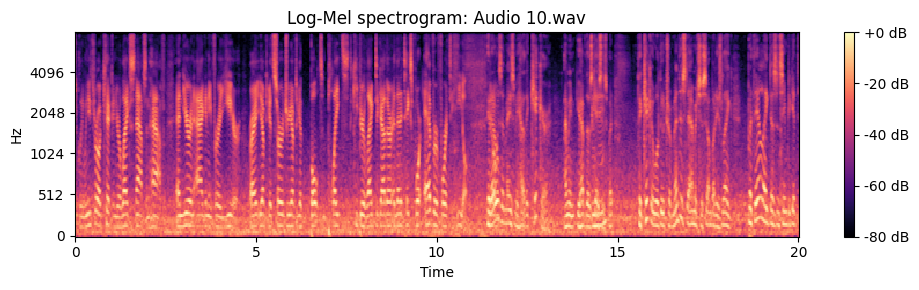

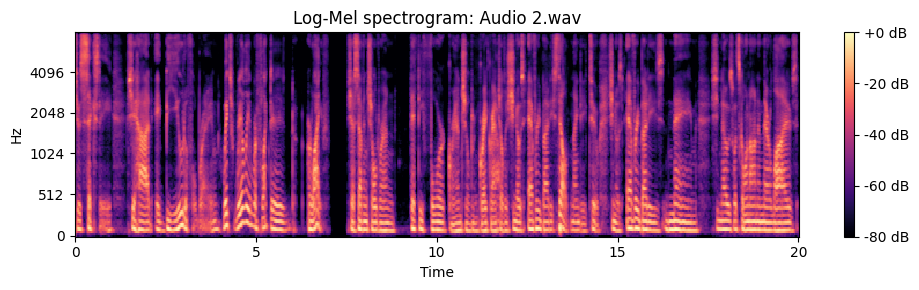

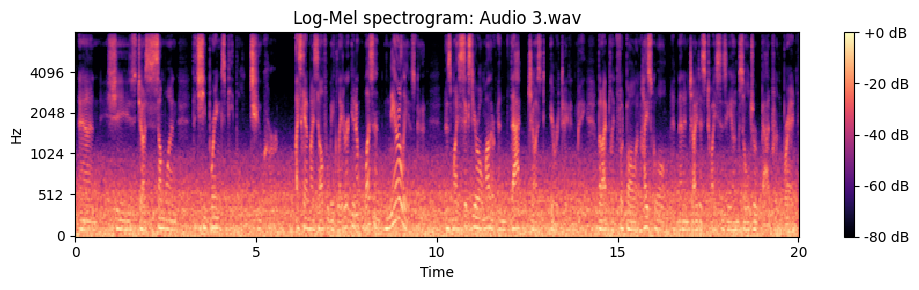

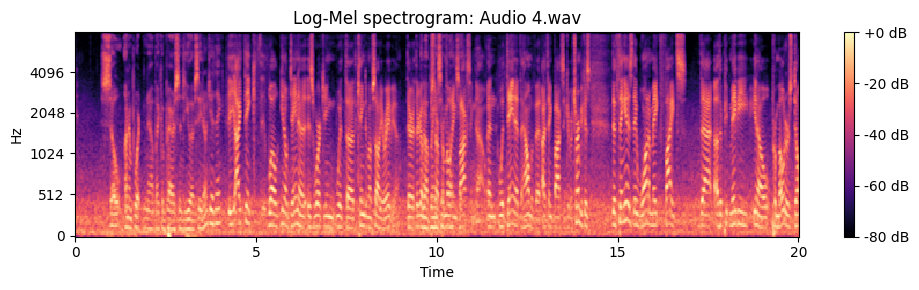

In [1]:
import os
import glob
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

audio_dir = "audio_files"
audio_files = sorted(glob.glob(os.path.join(audio_dir, "*.wav")))

# Just plotting first 5 ( audio 1, 10( due to sorting), 2, 3, 4)
for file_path in audio_files[:5]:
    y, sr = librosa.load(file_path, sr=16000)
    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    log_mel_spec = librosa.power_to_db(mel_spec, ref=np.max)

    plt.figure(figsize=(10, 3))
    librosa.display.specshow(log_mel_spec, sr=sr, x_axis='time', y_axis='mel')
    plt.colorbar(format='%+2.0f dB')
    plt.title(f"Log-Mel spectrogram: {os.path.basename(file_path)}")
    plt.tight_layout()
    plt.show()

Task 1 Observations

When I looked at the log mel spectrograms, the difference was very clear. The noisy audio files have bright colors scattered everywhere on the graph, which shows that there is a lot of background static interfering at all times. The clean audio files only have bright spots where the person is actually speaking, and the background is dark and empty.

Task 2

In [2]:
import scipy.signal as signal
import soundfile as sf

output_dir = "filtered_audio"
os.makedirs(output_dir, exist_ok=True)

def bandpass_filter(data, fs=16000, lowcut=80.0, highcut=7500.0, order=5):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = signal.butter(order, [low, high], btype='band')
    return signal.filtfilt(b, a, data)

def spectral_denoise(y):
    # convert frquency
    S = librosa.stft(y)
    magnitude, phase = librosa.magphase(S)

    # estimate nosie from 0.5s
    # STFT frame size is ~23ms, so 22 frames is ~0.5s
    noise_profile = np.mean(magnitude[:, :22], axis=1, keepdims=True)

    # subtract noise
    magnitude_clean = magnitude - noise_profile
    magnitude_clean = np.maximum(magnitude_clean, 0.0)

    # Convert back
    S_clean = magnitude_clean * phase
    return librosa.istft(S_clean)

for file_path in audio_files:
    file_name = os.path.basename(file_path)
    y, sr = librosa.load(file_path, sr=16000)

    # Filters
    y_bp = bandpass_filter(y, fs=sr)
    y_clean = spectral_denoise(y_bp)

    sf.write(os.path.join(output_dir, file_name), y_clean, sr)
print("Saved filtered audio.")

Saved filtered audio.


Task 2 Observations

After using the bandpass filter and the spectral denoising, the loud background hum in the noisy clips is mostly gone. Visually, if we plot the new audio, the background looks much darker and closer to the clean clips. I also checked if filtering hurts the clean clips. It does not ruin them, but it makes the voice sound slightly flat because the filter removes the extreme high and low pitches.

In [3]:
!pip install -U openai-whisper

Task 3

In [4]:
import whisper

model = whisper.load_model("base")

# Testing on one noisy file
test_file_name = "Audio 6.wav"
raw_path = os.path.join(audio_dir, test_file_name)
processed_path = os.path.join("filtered_audio", test_file_name)

experiments = [
    {"name": "Default Params", "args": {"fp16": False}},
    {"name": "Low Temperature (Strict)", "args": {"temperature": 0.0, "fp16": False}},
    {"name": "Initial Prompt (Context)", "args": {"initial_prompt": "The speaker is talking.", "fp16": False}},
    {"name": "Beam Size 5 (Deeper search)", "args": {"beam_size": 5, "fp16": False}}
]

def run_experiment(audio_path, file_type):
    print(f"\n[{file_type} audio]")
    for exp in experiments:
        result = model.transcribe(audio_path, **exp["args"])
        print(f"  {exp['name']}: {result['text'].strip()}")

run_experiment(raw_path, "Raw")
run_experiment(processed_path, "Processed")


[Raw audio]
  Default Params: so but those 15 round fights were unbelievable. They were unbelievable. They were unbelievable. Yeah, you could go back to Golden Age. Yeah, in terms of entertainment. Oh yeah. Those were the championship reps. Those were the greatest fights. Those last three rounds were crazy. I mean, it's such a war of attrition. You know, a lot of people think even a five round UFC fight. You...
  Low Temperature (Strict): so but those 15 round fights were unbelievable. They were unbelievable. They were unbelievable. Yeah, you could go back to Golden Age. Yeah, in terms of entertainment. Oh yeah. Those were the championship reps. Those were the greatest fights. Those last three rounds were crazy. I mean, it's such a war of attrition. You know, a lot of people think even a five round UFC fight. You...
  Initial Prompt (Context): So but those 15 round fights were unbelievable. They were unbelievable. Yeah, you could terms of golden age. Yeah, in terms of entertainment. O

Task 3 Observations

When transcribing the raw noisy audio, I had to change the parameters to get good results. Setting the temperature to 0 was very helpful because it stopped the model from guessing random words from the static. However, when I ran Whisper on the filtered audio we made in Task 2, it gave highly accurate text even on the default settings. This proves that cleaning the audio beforehand reduces the need to heavily tune the model parameters.

Task 4

In [5]:
import torch

vad_dir = "vad_audio"
os.makedirs(vad_dir, exist_ok=True)

vad_model, utils = torch.hub.load(repo_or_dir='snakers4/silero-vad', model='silero_vad', force_reload=True, trust_repo=True)
(get_speech_timestamps, save_audio, read_audio, VADIterator, collect_chunks) = utils

for file_path in audio_files:
    file_name = os.path.basename(file_path)

    wav = read_audio(file_path, sampling_rate=16000)

    timestamps = get_speech_timestamps(wav, vad_model, sampling_rate=16000)

    if timestamps:
        clean_wav = collect_chunks(timestamps, wav)
        save_audio(os.path.join(vad_dir, file_name), clean_wav, sampling_rate=16000)

print("Saved vad files.")

Downloading: "https://github.com/snakers4/silero-vad/zipball/master" to /root/.cache/torch/hub/master.zip


/usr/local/lib/python3.12/dist-packages/torchaudio/__init__.py:178: UserWarning: The 'bits_per_sample' parameter is not directly supported by TorchCodec AudioEncoder.
  return save_with_torchcodec(


Saved vad files.


Task 4 Observations

Using Voice Activity Detection to remove silences improved the process in a few ways. It made the transcription faster and stopped Whisper from hallucinating fake words during long silent pauses. The main issue I noticed was that if a speaker starts talking very quickly after a pause, the tool can sometimes accidentally clip off the very first sound of their sentence.